In [1]:
import time
import requests
from urllib.parse import urljoin, urlparse
from collections import deque
import heapq
from bs4 import BeautifulSoup
import networkx as nx
from datetime import datetime
import re
import pandas as pd
import os

BASE_URL = "http://localhost:3000"
USER_AGENT = "crawler/1.0"
REQUEST_TIMEOUT = 5
DISCOVERY_LIMIT = 300
MIN_INTERVAL = 3
MAX_INTERVAL = 120

session = requests.Session()
session.headers.update({"User-Agent": USER_AGENT})


def normalize_url(url):
    return url.rstrip("/")


def parse_timestamp(ts_str):
    try:
        dt = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S UTC")
        return dt.timestamp()
    except:
        return None


def compute_change_interval(history_timestamps):
    if len(history_timestamps) < 2:
        return None

    history_timestamps = sorted(history_timestamps)

    intervals = [
        history_timestamps[i] - history_timestamps[i - 1]
        for i in range(1, len(history_timestamps))
    ]

    return sum(intervals) / len(intervals)


def parse_page(html, url):
    soup = BeautifulSoup(html, "html.parser")

    # Get Node ID
    node_id_el = soup.select_one(".node-id b")
    node_id = node_id_el.get_text(strip=True) if node_id_el else None

    # Get Outgoing links
    outgoing = []
    for a in soup.select("a[href]"):
        full = urljoin(url, a["href"])
        if urlparse(full).netloc == urlparse(BASE_URL).netloc:
            outgoing.append(normalize_url(full))

    # Get Changed History

    history_items_container = soup.find(
        "div", style=lambda value: value and "margin-left" in value
    )

    history_timestamps = []
    last_change_time = None
    timestamp_pattern = re.compile(r"\((.*?)\)")

    if history_items_container:
        # find all child divs or li elements recursively
        for item in history_items_container.find_all(["div", "li"], recursive=True):
            text = item.get_text(" ", strip=True)
            match = timestamp_pattern.search(text)
            if match:
                ts = match.group(1)
                t = parse_timestamp(ts)
                if t:
                    history_timestamps.append(t)
                    if last_change_time is None or t > last_change_time:
                        last_change_time = t
    if last_change_time is None:
        last_change_time = time.time()

    # Get Total visits
    total_visits = 0
    for card in soup.select(".stat-card"):
        label_el = card.select_one(".stat-label")
        number_el = card.select_one(".stat-number")
        if label_el and number_el and label_el.get_text(strip=True) == "Total Visits":
            try:
                total_visits = int(number_el.get_text(strip=True))
            except:
                total_visits = 0
            break

    return {
        "node_id": node_id,
        "outgoing_urls": list(dict.fromkeys(outgoing)),
        "last_change_time": last_change_time,
        "total_visits": total_visits,
        "history_timestamps": history_timestamps,
    }


def discover(start_url):
    # Do BFS to discover pages
    q = deque([start_url])
    seen = set()
    url_to_info = {}
    visit_count = {}

    while q and len(seen) < DISCOVERY_LIMIT:
        u = q.popleft()
        if u in seen:
            continue

        try:
            r = session.get(u, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            info = parse_page(r.text, u)
        except:
            continue

        url_to_info[u] = info
        seen.add(u)
        visit_count[u] = 1  # first visit

        for nxt in info["outgoing_urls"]:
            if nxt not in seen:
                q.append(nxt)

    return url_to_info, visit_count


def compute_pagerank(url_to_info):
    G = nx.DiGraph()
    for url, info in url_to_info.items():
        if info:
            for tgt in info["outgoing_urls"]:
                G.add_edge(url, tgt)
    if len(G) == 0:
        return {}
    return nx.pagerank(G, alpha=0.85)


def calculate_metric(event_sequences):
    total_metric = 0
    for url, events in event_sequences.items():
        if not events or len(events) < 2:
            continue

        segments = []
        current_len = 1
        for i in range(1, len(events)):
            if events[i] == events[i - 1]:
                current_len += 1
            else:
                segments.append(current_len)
                current_len = 1
        segments.append(current_len)

        metric = sum(s**2 for s in segments) / len(events)
        total_metric += metric

    return total_metric / len(event_sequences) if event_sequences else 0


def should_stop_crawling(
    metric_history,
    iteration,
    total_visits,
    min_visits_per_page,
    url_to_info,
    visit_count,
    start_time,
    max_runtime_seconds=300,
):

    # Time limit (default 5 minutes)
    if time.time() - start_time > max_runtime_seconds:
        print(f"⏰ Time limit reached ({max_runtime_seconds}s)")
        return True

    # Need minimum data
    if iteration < 200 or len(metric_history) < 10:
        return False

    # Check metric convergence (last 10 values)
    recent_metrics = metric_history[-10:]
    if len(recent_metrics) >= 50:
        import statistics

        std_dev = statistics.stdev(recent_metrics)
        mean_metric = statistics.mean(recent_metrics)

        # Converged if std dev is small relative to mean
        if std_dev < 0.3 and std_dev / (mean_metric + 0.01) < 0.05:
            print(f"Metric converged: {mean_metric:.4f} ± {std_dev:.4f}")
            return True

    # Check if all pages visited enough times
    min_visits = min(visit_count.values()) if visit_count else 0
    if min_visits >= min_visits_per_page and len(url_to_info) > 10:
        avg_visits = sum(visit_count.values()) / len(visit_count)
        if avg_visits >= min_visits_per_page * 1.5:
            print(f"All pages well-explored (min: {min_visits}, avg: {avg_visits:.1f})")
            return True

    return False


def run():
    print("Initial discovery......")
    start_time = time.time()
    url_to_info, visit_count = discover(BASE_URL)

    last_fetch = {}  # last time the crawler fetched this URL
    last_changed = {}  # last recorded time the content actually changed in this URL.
    last_node = {}  # last known node_id to detect content updates of this URL.
    event_sequences = {}  # sequence of events for each page
    visits_without_update = {}  # Track consecutive visits without change
    metric_history = []  # Track metric over time

    now = time.time()
    for u, info in url_to_info.items():
        last_fetch[u] = now
        last_node[u] = info["node_id"]
        last_changed[u] = info.get("last_change_time", now)
        event_sequences[u] = ["v"]  # initial visit during discovery
        visits_without_update[u] = (
            1  # Start at 1 since we just visited during discovery
        )

    last_pr_time = 0
    pagerank = {}

    # Initialize refresh queue with learned intervals for all discored URLs

    # Priority queue: (next_refresh_time, url)
    refresh_queue = []
    for url, info in url_to_info.items():
        # get history safely
        history = info.get("history_timestamps", []) if info else []
        # print(history)
        predicted = compute_change_interval(history)
        # compute sensible defaults for scheduling
        time_since_change = time.time() - last_changed.get(url, time.time())
        pr_score = pagerank.get(url, 0)
        if predicted:
            interval = max(MIN_INTERVAL, min(MAX_INTERVAL, predicted))
        else:
            interval = max(MIN_INTERVAL, time_since_change)

        heapq.heappush(refresh_queue, (time.time() + interval, url))

    print("RE-CRAWLING LOOP - STOPS on metric convergence")

    iteration = 0
    total_updates = 0
    total_visits = 0

    while True:
        now = time.time()
        iteration += 1

        # Process next URL from priority queue
        if not refresh_queue:
            time.sleep(0.1)
            continue

        next_time, url = heapq.heappop(refresh_queue)

        # Still have time to refresh, push back and wait
        if next_time > now:
            heapq.heappush(refresh_queue, (next_time, url))
            sleep_time = min(0.1, next_time - now)
            time.sleep(sleep_time)
            continue

        # Skip if URL was removed
        if url not in url_to_info:
            continue

        # Refresh the URL - revistit and check for updates
        try:
            r = session.get(url, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            info = parse_page(r.text, url)

            old_node = last_node.get(url)
            new_node = info["node_id"]

            url_to_info[url] = info
            last_fetch[url] = time.time()
            visit_count[url] = visit_count.get(url, 0) + 1
            total_visits += 1

            # Track event type - ONLY count real content changes (node_id change)
            current_visits_without_update = visits_without_update.get(url, 0)

            if new_node != old_node:
                event_sequences.setdefault(url, []).append("u")  # update event
                visits_without_update[url] = 0  # Reset counter
                last_node[url] = new_node
                last_changed[url] = info.get("last_change_time", time.time())
                total_updates += 1
                print(
                    f"FOUND UPDATE at {url} → {new_node} (after {current_visits_without_update} visits)"
                )
            else:
                event_sequences.setdefault(url, []).append(
                    "v"
                )  # visit event (no change)
                visits_without_update[url] = current_visits_without_update + 1
                # Still update timestamp for staleness tracking if newer
                if info.get("last_change_time") and info[
                    "last_change_time"
                ] != last_changed.get(url):
                    last_changed[url] = info["last_change_time"]

            # Discover new pages
            for nxt in info["outgoing_urls"]:
                if nxt not in url_to_info and len(url_to_info) < DISCOVERY_LIMIT:
                    url_to_info[nxt] = None
                    visit_count[nxt] = 0
                    last_fetch[nxt] = 0
                    last_changed[nxt] = time.time()
                    last_node[nxt] = None
                    event_sequences[nxt] = []
                    visits_without_update[nxt] = 0
                    heapq.heappush(refresh_queue, (time.time(), nxt))

        except Exception as e:
            print(f"Error while refreshing {url}: {e}")
            last_fetch[url] = time.time()
            # On error, schedule a retry with backoff
            # small backoff so we don't hammer failing endpoints
            interval = min(MAX_INTERVAL, max(MIN_INTERVAL, 5))
            heapq.heappush(refresh_queue, (time.time() + interval, url))
            continue

        # Schedule next refresh with learned pattern (using history from page when available)
        time_since_change = time.time() - last_changed.get(url, time.time())
        pr_score = pagerank.get(url, 0)
        history = info.get("history_timestamps", []) if info else []

        predicted = compute_change_interval(history)

        if predicted:
            # optionally smooth prediction with last interval (exponential smoothing)
            # compute last observed interval if possible
            if len(sorted(history)) >= 2:
                last_interval = sorted(history)[-1] - sorted(history)[-2]
                # smooth: 70% predicted historical avg, 30% last interval
                interval = 0.7 * predicted + 0.3 * last_interval
            else:
                interval = predicted

            # clamp to allowed bounds
            interval = max(MIN_INTERVAL, min(MAX_INTERVAL, predicted))
        else:
            interval = max(MIN_INTERVAL, time_since_change)

        next_refresh = time.time() + interval
        heapq.heappush(refresh_queue, (next_refresh, url))

        # Periodic status report
        if iteration % 50 == 0:
            staleness = [
                now - last_changed[u] for u in url_to_info if u in last_changed
            ]
            avg_stale = sum(staleness) / len(staleness) if staleness else 0

            metric = calculate_metric(event_sequences)
            metric_history.append(metric)
            update_rate = total_updates / total_visits if total_visits > 0 else 0

            print("\n" + "=" * 60)
            print(f"\n  Iteration - {iteration}:")
            print(f"   Runtime: {(time.time() - start_time)/60:.1f} minutes")
            print(f"   Avg-staleness: {avg_stale:.2f}s")
            print(f"   Tracked pages: {len(url_to_info)}")
            print(f"   Metric: {metric:.4f}")
            print(
                f"   Update rate(updates/visist): {update_rate:.2%} ({total_updates}/{total_visits})"
            )

            print("\n" + "=" * 60)

            row = {
                "iteration": iteration,
                "runtime_min": (time.time() - start_time) / 60,
                "avg_staleness_s": avg_stale,
                "tracked_pages": len(url_to_info),
                "metric": metric,
                "update_rate": update_rate,
                "total_updates": total_updates,
                "total_visits": total_visits,
            }

            # Append row to CSV
            df = pd.DataFrame([row])
            df.to_csv(
                "crawler_summary.csv",
                mode="a",
                header=not os.path.isfile("crawler_summary.csv"),
                index=False,
            )

            # Check stopping criteria
            if should_stop_crawling(
                metric_history,
                iteration,
                total_visits,
                10,
                url_to_info,
                visit_count,
                start_time,
            ):
                pagerank = compute_pagerank(url_to_info)
                top_k = 10
                ranked_pages = sorted(
                    pagerank.items(), key=lambda x: x[1], reverse=True
                )
                print("\n" + "=" * 60)
                print("STOPPING CRITERIA MET")
                print("=" * 60)
                print(f"Final  Metric: {metric:.4f}")
                print(f"Total runtime: {(time.time() - start_time)/60:.1f} minutes")
                print(f"Total visits: {total_visits}")
                print(f"Total updates detected: {total_updates}")
                print(f"Average staleness: {avg_stale:.2f}s")
                print(f"Tracked pages: {len(url_to_info)}")
                print("\nTop Ranked Pages:")
                for i, (u, score) in enumerate(ranked_pages[:top_k], start=1):
                    print(f"   {i}. {u}  → PR={score:.6f}")
                break

            print()


if __name__ == "__main__":
    run()

/Users/darmojudeekshitha/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Initial discovery......
RE-CRAWLING LOOP - STOPS on metric convergence
FOUND UPDATE at http://localhost:3000 → u2ma4d0w85l1 (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_24pqbcsg → oq86vsnpsnw1 (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_lqj8mmr0 → hn4mgrmfttqq (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_edxrcas4 → 9i69ybypu7vs (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_tqhq3dyk → qb1fj27cckrq (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_263luawg → lxvixqi2cq8g (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_j7xnjasv → lwcgtwjy65ke (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_li43bz8w → 3h0w75kjncpg (after 1 visits)
FOUND UPDATE at http://localhost:3000/page_r9frsvrw → qjxcmeufaxxh (after 1 visits)


  Iteration - 50:
   Runtime: 0.1 minutes
   Avg-staleness: 1.97s
   Tracked pages: 53
   Metric: 0.6226
   Update rate(updates/visist): 42.86% (9/21)


FOUND UPDATE at http://localhost

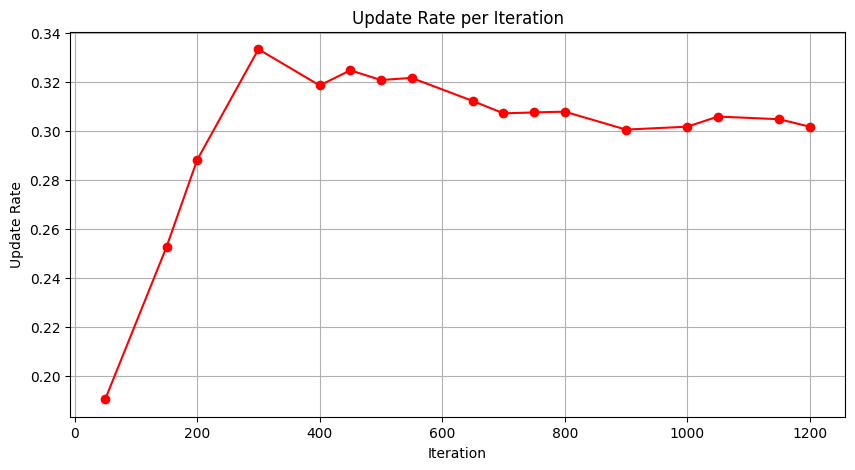

In [29]:
import matplotlib.pyplot as plt

import pandas as pd

df = pd.read_csv("crawler_summary.csv")
plt.figure(figsize=(10, 5))
plt.plot(df["iteration"], df["update_rate"], marker="o", color="red")
plt.title("Update Rate per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Update Rate")
plt.grid(True)
plt.show()